In [1]:
import cudf as cf
import cupy as cp

import optuna
# Use native XGBoost Dask API instead of dask-ml
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor

import plotly.express as px
from plotly.io import show

In [2]:
# Load the processed data
print("Loading csv data...")
df_with_encoding = cf.read_csv("./tmp/unfv_route_29_no_na_dropped_with_encoding.csv")
df_without_encoding = cf.read_csv("./tmp/df_29_no_na_dropped_without_encoding.csv")
print(f"Columns: {df_with_encoding.columns.tolist()}")

Loading csv data...
Columns: ['route', 'trip_id', 'stopid', 'actual_arrival', 'hour', 'day_of_week', 'month', 'day_of_year', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'delay_seconds', 'nearest_whole_hour', 'Climate ID', 'Temp (°C)', 'Dew Point Temp (°C)', 'Rel Hum (%)', 'Wind Spd (km/h)', 'Visibility (km)', 'Stn Press (kPa)', 'Precip. Amount (mm)', 'bound', 'thrustreet', 'thrusteet_Dufferin St', 'thrusteet_Manitoba Dr', 'thrusteet_Nova Scotia Ave', 'thrusteet_Princes Blvd', "thrusteet_Princes' Blvd", "thrusteet_Princes' Gates Loop", 'thrusteet_Saskatchewan Rd', 'thrusteet_Wilson Ave', 'thrusteet_Wilson Station']


In [76]:
df_without_encoding.columns

Index(['route', 'trip_id', 'stopid', 'thrusteet', 'actual_arrival', 'hour',
       'day_of_week', 'month', 'day_of_year', 'hour_sin', 'hour_cos',
       'day_of_week_sin', 'day_of_week_cos', 'delay_seconds',
       'nearest_whole_hour', 'Climate ID', 'Temp (°C)', 'Dew Point Temp (°C)',
       'Rel Hum (%)', 'Wind Spd (km/h)', 'Visibility (km)', 'Stn Press (kPa)',
       'Precip. Amount (mm)', 'bound'],
      dtype='object')

In [3]:
df_with_encoding.dtypes

route                            float64
trip_id                            int64
stopid                             int64
actual_arrival                    object
hour                               int64
day_of_week                        int64
month                              int64
day_of_year                        int64
hour_sin                         float64
hour_cos                         float64
day_of_week_sin                  float64
day_of_week_cos                  float64
delay_seconds                    float64
nearest_whole_hour                object
Climate ID                       float64
Temp (°C)                        float64
Dew Point Temp (°C)              float64
Rel Hum (%)                      float64
Wind Spd (km/h)                  float64
Visibility (km)                  float64
Stn Press (kPa)                  float64
Precip. Amount (mm)              float64
bound                              int64
thrustreet                        object
thrusteet_Duffer

In [4]:
df_with_encoding.isna().sum()

route                            0
trip_id                          0
stopid                           0
actual_arrival                   0
hour                             0
day_of_week                      0
month                            0
day_of_year                      0
hour_sin                         0
hour_cos                         0
day_of_week_sin                  0
day_of_week_cos                  0
delay_seconds                    0
nearest_whole_hour               0
Climate ID                       0
Temp (°C)                        0
Dew Point Temp (°C)              0
Rel Hum (%)                      0
Wind Spd (km/h)                  0
Visibility (km)                  0
Stn Press (kPa)                  0
Precip. Amount (mm)              0
bound                            0
thrustreet                       0
thrusteet_Dufferin St            0
thrusteet_Manitoba Dr            0
thrusteet_Nova Scotia Ave        0
thrusteet_Princes Blvd           0
thrusteet_Princes' B

In [5]:
df_with_encoding['delay_seconds'].describe()

count    2.018320e+06
mean     4.122698e+02
std      1.074387e+03
min      1.000000e-03
25%      8.096875e+01
50%      2.012925e+02
75%      4.630000e+02
max      3.779996e+04
Name: delay_seconds, dtype: float64

## EDA

Correlation Analysis of dataset with categorical column

In [6]:
## correlation analysis of features with the target variable and show it in table
# remove thrusteet
df_corr_encoded_data = df_with_encoding.drop(columns=['thrustreet', 'route', 'trip_id', 'Climate ID', 'actual_arrival', 'nearest_whole_hour']).to_pandas()  # Convert to pandas for correlation analysis
correlation_matrix = df_corr_encoded_data.corr(method='pearson')
target_correlation = correlation_matrix['delay_seconds'].drop('delay_seconds')  
print("Correlation of features with delay_seconds:")
print(target_correlation.sort_values(ascending=False))
# Visualize the correlation of features with the target variable using a bar chart
correlation_df = target_correlation.reset_index()
correlation_df.columns = ['Correlation', 'Feature']
fig = px.bar(correlation_df, x='Feature', y='Correlation', title='Correlation of Features with delay_seconds')
show(fig)

Correlation of features with delay_seconds:
hour_cos                         0.104916
day_of_year                      0.055694
month                            0.051963
Rel Hum (%)                      0.034137
day_of_week                      0.028482
hour_sin                         0.025287
Dew Point Temp (°C)              0.021854
Visibility (km)                  0.013999
thrusteet_Dufferin St            0.010689
Temp (°C)                        0.008008
thrusteet_Nova Scotia Ave        0.007207
day_of_week_sin                  0.006528
stopid                           0.004544
thrusteet_Princes Blvd           0.003976
hour                             0.001682
thrusteet_Manitoba Dr            0.000030
thrusteet_Wilson Ave            -0.000288
Precip. Amount (mm)             -0.001713
bound                           -0.002401
thrusteet_Saskatchewan Rd       -0.003141
thrusteet_Princes' Gates Loop   -0.003574
thrusteet_Wilson Station        -0.005237
Stn Press (kPa)                 

Correlation Analysis of dataset without categorical column

In [7]:
## correlation analysis of features with the target variable and show it in table
# remove thrusteet
df_corr_without_encoding = df_without_encoding.drop(columns=['thrusteet', 'route', 'trip_id', 'Climate ID', 'actual_arrival', 'nearest_whole_hour']).to_pandas()  # Convert to pandas for correlation analysis
correlation_matrix = df_corr_without_encoding.corr(method='pearson')
target_correlation = correlation_matrix['delay_seconds'].drop('delay_seconds')  
print("Correlation of features with delay_seconds:")
print(target_correlation.sort_values(ascending=False))
# Visualize the correlation of features with the target variable using a bar chart
correlation_df = target_correlation.reset_index()
correlation_df.columns = ['Correlation', 'Feature']
fig = px.bar(correlation_df, x='Feature', y='Correlation', title='Correlation of Features with delay_seconds')
show(fig)

Correlation of features with delay_seconds:
hour_cos               0.104916
day_of_year            0.055694
month                  0.051963
Rel Hum (%)            0.034137
day_of_week            0.028482
hour_sin               0.025287
Dew Point Temp (°C)    0.021854
Visibility (km)        0.013999
Temp (°C)              0.008008
day_of_week_sin        0.006528
stopid                 0.004544
hour                   0.001682
Precip. Amount (mm)   -0.001713
bound                 -0.002401
Stn Press (kPa)       -0.011502
Wind Spd (km/h)       -0.027719
day_of_week_cos       -0.050012
Name: delay_seconds, dtype: float64


VIF (Variance Inflation Factor) (categorical column included)

In [8]:
# calculate variance inflation factor (VIF) for each feature to check for multicollinearity
features = df_corr_encoded_data.drop(columns=['delay_seconds']).columns
vif_data = cf.DataFrame()
vif_data['Feature'] = features
vif_data['VIF'] = [variance_inflation_factor(df_corr_encoded_data[features].values, i) for i in range(len(features))]
print("Variance Inflation Factor (VIF) for each feature:")
print(vif_data.sort_values(by='VIF', ascending=False))

Variance Inflation Factor (VIF) for each feature:
                          Feature          VIF
17          thrusteet_Dufferin St  9184.991381
9                       Temp (°C)   206.640780
10            Dew Point Temp (°C)   187.518641
25       thrusteet_Wilson Station   182.465073
4                     day_of_year   132.041464
3                           month   131.895337
22  thrusteet_Princes' Gates Loop    87.488951
21        thrusteet_Princes' Blvd    80.373989
23      thrusteet_Saskatchewan Rd    57.670795
11                    Rel Hum (%)    31.568989
19      thrusteet_Nova Scotia Ave    29.858247
20         thrusteet_Princes Blvd    28.516488
2                     day_of_week     3.081949
7                 day_of_week_sin     2.890784
5                        hour_sin     2.690077
1                            hour     2.547565
24           thrusteet_Wilson Ave     2.266758
16                          bound     1.722649
13                Visibility (km)     1.713895
6         

VIF (categorical column excluded)

In [9]:
# calculate variance inflation factor (VIF) for each feature to check for multicollinearity
features = df_corr_without_encoding.drop(columns=['delay_seconds']).columns
vif_data = cf.DataFrame()
vif_data['Feature'] = features
vif_data['VIF'] = [variance_inflation_factor(df_corr_without_encoding[features].values, i) for i in range(len(features))]
print("Variance Inflation Factor (VIF) for each feature:")
print(vif_data.sort_values(by='VIF', ascending=False))

Variance Inflation Factor (VIF) for each feature:
                Feature          VIF
14      Stn Press (kPa)  1132.236973
3                 month   642.029050
4           day_of_year   561.660287
11          Rel Hum (%)   531.015955
9             Temp (°C)   364.596439
10  Dew Point Temp (°C)   206.477228
13      Visibility (km)    30.726929
2           day_of_week    11.617557
1                  hour    10.329563
12      Wind Spd (km/h)     4.821914
5              hour_sin     3.277319
7       day_of_week_sin     2.922062
0                stopid     2.062887
6              hour_cos     1.427345
8       day_of_week_cos     1.237233
15  Precip. Amount (mm)     1.088881
16                bound     1.015349


Shapiro-Wilk test

In [10]:
# do shapiro wilk test for normality of the target variable
stat, p = shapiro(df_with_encoding['delay_seconds'].to_pandas())
print(f"Shapiro-Wilk Test: Statistics={stat}, p-value={p}")
if p > 0.05:
    print("The target variable is normally distributed (fail to reject H0)")
else:
    print("The target variable is not normally distributed (reject H0)")

Shapiro-Wilk Test: Statistics=0.23309105897174687, p-value=1.6280788620677056e-236
The target variable is not normally distributed (reject H0)


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 2018320.



In [11]:
df_with_encoding.head()

,route,trip_id,stopid,actual_arrival,hour,day_of_week,month,day_of_year,hour_sin,hour_cos,...,thrustreet,thrusteet_Dufferin St,thrusteet_Manitoba Dr,thrusteet_Nova Scotia Ave,thrusteet_Princes Blvd,thrusteet_Princes' Blvd,thrusteet_Princes' Gates Loop,thrusteet_Saskatchewan Rd,thrusteet_Wilson Ave,thrusteet_Wilson Station
0,29.0,52553080,34800,2025-01-01 00:06:13.000,0,2,1,1,0.0,1.0,...,Princes' Blvd,0,0,0,0,1,0,0,0,0
1,29.0,172354080,1361,2025-01-01 00:07:26.027,0,2,1,1,0.0,1.0,...,Dufferin St,1,0,0,0,0,0,0,0,0
2,29.0,52553080,2815,2025-01-01 00:07:35.995,0,2,1,1,0.0,1.0,...,Saskatchewan Rd,0,0,0,0,0,0,1,0,0
3,29.0,172354080,9023,2025-01-01 00:07:58.226,0,2,1,1,0.0,1.0,...,Dufferin St,1,0,0,0,0,0,0,0,0
4,29.0,52553080,18388,2025-01-01 00:08:48.000,0,2,1,1,0.0,1.0,...,Dufferin St,1,0,0,0,0,0,0,0,0


### Top 10 stop id with highest delay

In [12]:
# get top stopid with highest positive delay incidents
stopid_counts = df_with_encoding.groupby('stopid').size().reset_index(name='Count')
stopid_counts = stopid_counts.sort_values('Count', ascending=False)
top_routes = stopid_counts.head(10)
top_routes.stopid = top_routes.stopid.astype(str)  # Convert stopid to string for better visualization

fig = px.bar(top_routes, x='stopid', y='Count', title='Top 10 Stops with Highest positive delay incidents',
             color='Count', color_continuous_scale='viridis')
fig.update_layout(xaxis_title='stopid', yaxis_title='Count')

fig.show()

### Delay by thrustreet

In [13]:
# delay by thrustreet > 0 delay seconds
thrustreet_counts = df_with_encoding.groupby('thrustreet').size().reset_index(name='Count')
thrustreet_counts = thrustreet_counts.sort_values('Count', ascending=False)
top_thrustreets = thrustreet_counts.head(5)
top_thrustreets.thrustreet = top_thrustreets.thrustreet.astype(str
)  # Convert thrustreet to string for better visualization
fig = px.bar(top_thrustreets, x='thrustreet', y='Count', title='Top 5 Thrustreets with Highest positive delay incidents',
             color='Count', color_continuous_scale='viridis')
fig.update_layout(xaxis_title='thrustreet', yaxis_title='Count')
fig.show()


### Delay by hour

In [14]:
# delay by hour with > 0 delay seconds
hour_counts = df_with_encoding['hour'].value_counts().sort_index()
hour_data = cf.DataFrame({'Hour': hour_counts.index, 'Count': hour_counts.values})
fig = px.bar(hour_data, x='Hour', y='Count', title='Delay Incidents by Hour of the Day', color='Hour')
fig.update_layout(xaxis_title='Hour of the Day', yaxis_title='Count')
fig.show()

### Delay by week

In [15]:
# delay by week with > 0 delay seconds
day_counts = df_with_encoding['day_of_week'].value_counts().sort_index()
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
day_data = cf.DataFrame({'Day of the Week': day_order, 'Count': day_counts})

fig = px.bar(day_data, x='Day of the Week', y='Count', title='Delay Incidents by Day of the Week', color='Day of the Week')
fig.update_layout(xaxis_title='Day of the Week', yaxis_title='Count')

fig.show()

### Delay by month

In [16]:
# delay by month with > 0 delay seconds
month_counts = df_with_encoding['month'].value_counts().sort_index()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

month_data = cf.DataFrame({'Month': month_order, 'Count': month_counts})

fig = px.pie(month_data, values='Count', names='Month', title='Frequency of Delays by Month',
             hole=0.4, color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_traces(textinfo='percent+label', pull=[0.1, 0, 0, 0, 0, 0])

fig.show()

In [17]:
print(f"\nFeature shape(Dropped): {df_with_encoding.shape[0]:,} rows x {df_with_encoding.shape[1]} columns")


Feature shape(Dropped): 2,018,320 rows x 33 columns


## Model with encoded categorical data

### Simple Model

In [44]:
cp.get_default_memory_pool().free_all_blocks()

In [45]:
df_encoded_X = df_with_encoding.drop(columns=['delay_seconds', 'route', 'trip_id', 'thrustreet', 'actual_arrival', 'nearest_whole_hour'])
df_encoded_y = df_with_encoding['delay_seconds']

In [46]:
X_train_encoded, X_test_encoded, y_train_encoded, y_test_encoded = train_test_split(
    df_encoded_X,
    df_encoded_y,
    test_size=0.2,
    random_state=42
)

print(f"\nTrain size: {len(X_train_encoded):,}")
print(f"Test size: {len(X_test_encoded):,}")


Train size: 1,614,656
Test size: 403,664


In [47]:
X_train_encoded_cupy = X_train_encoded.to_cupy()
y_train_encoded_cupy = y_train_encoded.to_cupy()
X_test_encoded_cupy = X_test_encoded.to_cupy()
y_test_encoded_cupy = y_test_encoded.to_cupy()

In [48]:
# # Define Optuna objective function for hyperparameter tuning
import numpy as np
def objective(trial):
    """Optuna objective function to minimize RMSE using native XGBoost Dask API"""
    
    # Define hyperparameter search space
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'device': 'cuda',
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 10_000,20_000, step=1000),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    
    n_samples = X_train_encoded_cupy.shape[0]
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    avg_r2_squares = np.zeros(kf.get_n_splits())
    
    # KFold.split only needs sample count — pass a range, no GPU→CPU data transfer
    for i, (train_index, val_index) in enumerate(kf.split(range(n_samples))):
        # Index cupy arrays directly with numpy indices
        dtrain = xgb.QuantileDMatrix(X_train_encoded_cupy[train_index], label=y_train_encoded_cupy[train_index])
        dval = xgb.QuantileDMatrix(X_train_encoded_cupy[val_index], label=y_train_encoded_cupy[val_index], ref=dtrain)

        model = xgb.train(params, dtrain, evals=[(dval, 'eval')], 
                      verbose_eval=False, early_stopping_rounds=100)
    
        # Make predictions (returns numpy array)
        y_pred = model.predict(dval)
    
        # Convert only the fold's labels to numpy for R2 score calculation
        y_fold = y_train_encoded_cupy[val_index].get()
        r2_square = r2_score(y_fold, y_pred)
        avg_r2_squares[i] = r2_square

    # Return average R2 square across folds
    return float(np.mean(avg_r2_squares))

print("Objective function defined with native XGBoost and Optuna GPU")

Objective function defined with native XGBoost and Optuna GPU


In [49]:
# Run Optuna hyperparameter optimization
print("Starting Optuna hyperparameter optimization...")
print("XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.")
print("This may take a while...\n")



# Create study
study_simple_encoded = optuna.create_study(
    direction='maximize',  # Maximize R2 square
    study_name='xgboost_delay_prediction',
    sampler=optuna.samplers.TPESampler(seed=42),
)

# Run optimization sequentially (XGBoost Dask handles parallelization internally)
n_trials = 50  # Total number of trials

print(f"Running {n_trials} trials...")

# Run sequential optimization - each trial uses Dask cluster efficiently
study_simple_encoded.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)
print(f"\nBest trial: #{study_simple_encoded.best_trial.number}")
print(f"Best RMSE: {study_simple_encoded.best_value:.4f}")
print("\nBest hyperparameters:")
for key, value in study_simple_encoded.best_params.items():
    print(f"  {key}: {value}")

[I 2026-03-22 20:01:04,510] A new study created in memory with name: xgboost_delay_prediction


Starting Optuna hyperparameter optimization...
XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.
This may take a while...

Running 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]

/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:01:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:01:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:01:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:01:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-22 20:01:05,362] Trial 0 finished with value: 0.7700171743897142 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 18000, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746}. Best is trial 0 with value: 0.7700171743897142.


...

[I 2026-03-22 20:02:09,478] Trial 47 finished with value: 0.8184616786830308 and parameters: {'max_depth': 10, 'learning_rate': 0.17039824298042, 'n_estimators': 19000, 'subsample': 0.8386917183330744, 'colsample_bytree': 0.8563797726741232}. Best is trial 46 with value: 0.8466728518663409.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:02:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:02:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:02:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:02:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-22 20:02:11,055] Trial 48 finished with value: 0.8461583814595015 and parameters: {'max_depth': 10, 'learning_rate': 0.2922165589443714, 'n_estimators': 18000, 'subsample': 0.8791226956653672, 'colsample_bytree': 0.6206602551551839}. Best is trial 46 with value: 0.8466728518663409.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:02:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:02:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:02:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:02:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-22 20:02:12,786] Trial 49 finished with value: 0.8461860865883197 and parameters: {'max_depth': 10, 'learning_rate': 0.2943436988322272, 'n_estimators': 20000, 'subsample': 0.8820115319025533, 'colsample_bytree': 0.6207486800581571}. Best is trial 46 with value: 0.8466728518663409.

OPTIMIZATION COMPLETE!

Best trial: #46
Best RMSE: 0.8467

Best hyperparameters:
  max_depth: 10
  learning_rate: 0.28914767842642247
  n_estimators: 18000
  subsample: 0.8433171474204375
  colsample_bytree: 0.6793573146591657


In [50]:
fig = optuna.visualization.plot_param_importances(study_simple_encoded)
show(fig)

In [51]:
study_simple_encoded.best_params

{'max_depth': 10,
 'learning_rate': 0.28914767842642247,
 'n_estimators': 18000,
 'subsample': 0.8433171474204375,
 'colsample_bytree': 0.6793573146591657}

In [52]:
cp.get_default_memory_pool().free_all_blocks()

In [53]:
# Train final model with best parameters using native XGBoost Dask API
print("Training final model with best hyperparameters...")
print("="*60)

# Get best parameters
best_params_simple = study_simple_encoded.best_params.copy()
best_params_clean = {k: v for k, v in best_params_simple.items() if k != 'num_boost_round'}
best_params_simple['objective'] = 'reg:squarederror'
best_params_simple['tree_method'] = 'hist'  # Required for Dask

# Create QuantileDMatrix for training
dtrain = xgb.DMatrix(X_train_encoded_cupy, y_train_encoded_cupy)

# Train final model using native Dask XGBoost
output_simple_encoded = xgb.train(
    best_params_simple,
    dtrain,
)

Training final model with best hyperparameters...


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning:

[20:02:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




In [54]:
dtest = xgb.DMatrix(X_test_encoded_cupy)
y_pred_dropped = output_simple_encoded.predict(dtest)

In [55]:
rmse_simple_encoded = np.sqrt(mean_squared_error(y_test_encoded_cupy.get(), y_pred_dropped))
r2_simple_encoded = r2_score(y_test_encoded_cupy.get(), y_pred_dropped)
mae_simple_encoded = mean_absolute_error(y_test_encoded_cupy.get(), y_pred_dropped)
print("Final Model Performance on Test Set:")
print(f"  RMSE: {rmse_simple_encoded:.4f}")
print(f"  R²: {r2_simple_encoded:.4f}")
print(f"  MAE: {mae_simple_encoded:.4f}")

Final Model Performance on Test Set:
  RMSE: 415.5318
  R²: 0.8445
  MAE: 257.5950


In [56]:
import pandas as pd
map_with_features = output_simple_encoded.get_score(importance_type='gain')
feature_importance_df = pd.DataFrame(map_with_features.items(), columns=['Feature', 'Gain'])
feature_importance_df['Feature'] = feature_importance_df['Feature'].apply(lambda x: df_encoded_X.columns[int(x[1:])])
feature_importance_df = feature_importance_df.sort_values(by='Gain', ascending=False)
print(feature_importance_df)

                          Feature          Gain
2                     day_of_week  1.410172e+09
4                     day_of_year  9.284892e+08
3                           month  7.735034e+08
9                       Temp (°C)  5.515524e+08
14                Stn Press (kPa)  4.461353e+08
11                    Rel Hum (%)  3.776128e+08
10            Dew Point Temp (°C)  3.692168e+08
6                        hour_cos  3.534350e+08
5                        hour_sin  1.589283e+08
7                 day_of_week_sin  1.334890e+08
8                 day_of_week_cos  7.530457e+07
13                Visibility (km)  3.720991e+07
1                            hour  3.202343e+07
12                Wind Spd (km/h)  3.091663e+07
15            Precip. Amount (mm)  2.680577e+07
18      thrusteet_Nova Scotia Ave  1.475507e+07
20        thrusteet_Princes' Blvd  6.896258e+06
22      thrusteet_Saskatchewan Rd  6.023104e+06
19         thrusteet_Princes Blvd  5.159788e+06
21  thrusteet_Princes' Gates Loop  3.982

In [31]:
output_simple_encoded.set_param({'device': 'cuda'})

In [32]:
import shap
shap_values = output_simple_encoded.predict(dtest, pred_contribs=True)
explainer = shap.TreeExplainer(output_simple_encoded)
shap_values = explainer.shap_values(X_test_encoded_cupy)
feature_names = df_encoded_X.columns.tolist()

In [33]:
shap_values

array([[ 5.48808384e+00,  2.83058681e+01,  3.50067449e+00, ...,
        -3.95465605e-02,  9.86005180e-05,  8.97475243e-01],
       [-4.36121225e+00,  3.91066513e+01, -1.21786353e+03, ...,
        -6.41848445e-02,  1.79407769e-04,  1.44743755e-01],
       [-6.62146628e-01, -4.73144960e+00,  3.22360611e+00, ...,
        -6.76129088e-02,  6.95266281e-05,  3.86012137e-01],
       ...,
       [ 1.24240085e-01, -4.22961426e+01, -3.03849678e+01, ...,
        -4.46122959e-02,  1.07731263e-04,  2.01735407e-01],
       [-9.82090378e+00, -9.63897324e+01, -1.66151104e+01, ...,
        -5.51521145e-02,  1.79407769e-04,  1.60988614e-01],
       [ 1.37348928e+01, -1.86125412e+01, -7.75191116e+00, ...,
        -3.31835039e-02,  1.79407769e-04, -2.30238527e-01]],
      shape=(403664, 27), dtype=float32)

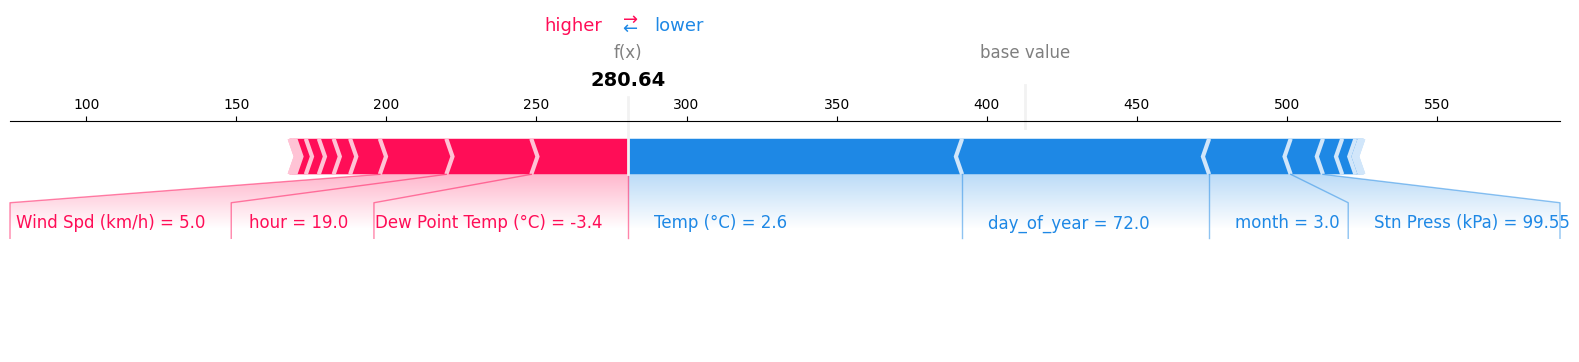

In [34]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    X_test_encoded_cupy[0, :].get(),
    feature_names=feature_names,
    matplotlib=True,
)

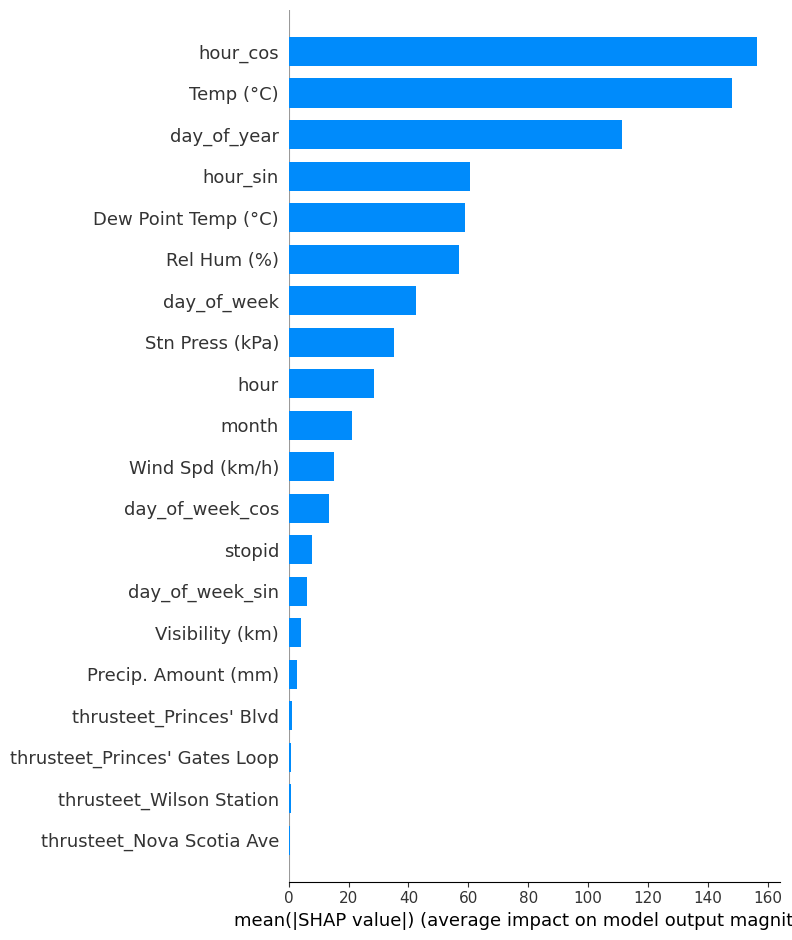

In [35]:
shap.summary_plot(shap_values, X_test_encoded_cupy, plot_type="bar", feature_names=feature_names)

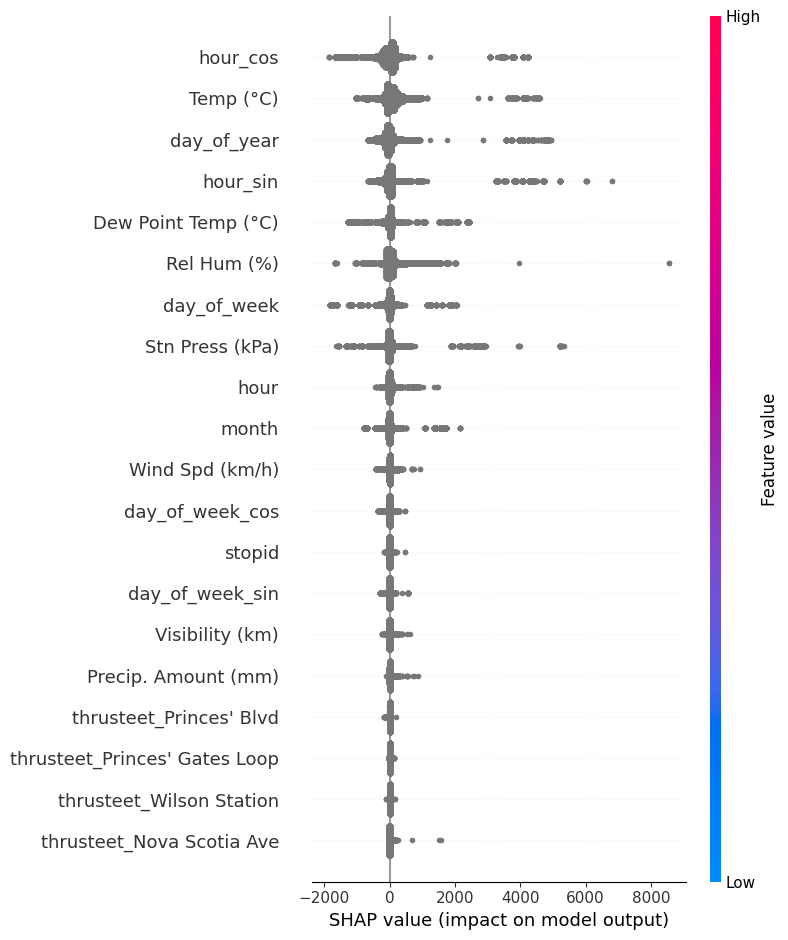

In [36]:
shap.summary_plot(shap_values, X_test_encoded_cupy, feature_names=feature_names)

### Complex Model

In [57]:
def objective(trial):
    """Optuna objective function to minimize RMSE using native XGBoost Dask API"""
    
    # Define hyperparameter search space
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'device': 'cuda',
        # Use max_leaves instead of or alongside max_depth for more flexible trees
        'max_leaves': trial.suggest_int('max_leaves', 31, 512),
        'grow_policy': 'lossguide',  # Required for max_leaves to work with hist
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 10_000,15_000, step=1000),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        # L2 regularization on leaf weights (default=1)
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),

        # L1 regularization on leaf weights (default=0)
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),

        # Minimum loss reduction for further partitioning (default=0)
        'gamma': trial.suggest_float('gamma', 0, 5.0),

        # Minimum child weight — prevents overfitting to small leaf nodes
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'colsample_bynode': trial.suggest_float('colsample_bynode', 0.5, 1.0),
        
    }
    
    n_samples = X_train_encoded_cupy.shape[0]
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
        
    avg_r2_scores = np.zeros(kf.get_n_splits())
    
    # KFold.split only needs sample count — pass a range, no GPU→CPU data transfer
    for i, (train_index, val_index) in enumerate(kf.split(range(n_samples))):
        # Index cupy arrays directly with numpy indices
        dtrain = xgb.QuantileDMatrix(X_train_encoded_cupy[train_index], label=y_train_encoded_cupy[train_index])
        dval = xgb.QuantileDMatrix(X_train_encoded_cupy[val_index], label=y_train_encoded_cupy[val_index], ref=dtrain)

        model = xgb.train(params, dtrain, evals=[(dval, 'eval')], 
                      verbose_eval=False, early_stopping_rounds=100)
    
        # Make predictions (returns numpy array)
        y_pred = model.predict(dval)
    
        # Convert only the fold's labels to numpy for RMSE calculation
        y_fold = y_train_encoded_cupy[val_index].get()
        r2_scores = r2_score(y_fold, y_pred)
        avg_r2_scores[i] = r2_scores

        trial.report(np.mean(avg_r2_scores), i)
        if trial.should_prune():
            raise optuna.TrialPruned()
        
    # Return average R2 across folds
    return float(np.mean(avg_r2_scores))

print("Objective function defined with native XGBoost and Optuna GPU")

Objective function defined with native XGBoost and Optuna GPU


In [58]:
# Run Optuna hyperparameter optimization
print("Starting Optuna hyperparameter optimization...")
print("XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.")
print("This may take a while...\n")



# Create study with optuna
study_complex_encoded = optuna.create_study(
    direction='maximize',  # Maximize R2 square
    study_name='xgboost_delay_prediction',
    sampler=optuna.samplers.TPESampler(seed=42),
)

# Run optimization sequentially (XGBoost Dask handles parallelization internally)
n_trials = 50  # Total number of trials

print(f"Running {n_trials} trials...")

# Run sequential optimization - each trial uses Dask cluster efficiently
study_complex_encoded.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)
print(f"\nBest trial: #{study_complex_encoded.best_trial.number}")
print(f"Best RMSE: {study_complex_encoded.best_value:.4f}")
print("\nBest hyperparameters:")
for key, value in study_complex_encoded.best_params.items():
    print(f"  {key}: {value}")

[I 2026-03-22 20:03:08,918] A new study created in memory with name: xgboost_delay_prediction


Starting Optuna hyperparameter optimization...
XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.
This may take a while...

Running 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]

/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:03:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:03:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:03:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:03:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-22 20:03:11,021] Trial 0 finished with value: 0.7625290309181156 and parameters: {'max_leaves': 211, 'learning_rate': 0.24517932047070642, 'n_estimators': 14000, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_lambda': 0.004207053950287938, 'reg_alpha': 0.0017073967431528124, 'gamma': 4.330880728874676, 'min_child_weight': 31, 'colsample_bylevel': 0.8540362888980227, 'colsample_bynode': 0.5102922471479012}. Best is trial 0 with value: 0.7625290309181156.


...

[I 2026-03-22 20:03:58,918] Trial 47 pruned. 


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:03:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




[I 2026-03-22 20:03:59,318] Trial 48 pruned. 


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:03:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




[I 2026-03-22 20:03:59,682] Trial 49 pruned. 

OPTIMIZATION COMPLETE!

Best trial: #32
Best RMSE: 0.8036

Best hyperparameters:
  max_leaves: 446
  learning_rate: 0.29915861423737067
  n_estimators: 15000
  subsample: 0.6890716956379109
  colsample_bytree: 0.9531291833577744
  reg_lambda: 0.10172523986118526
  reg_alpha: 0.10155128468277076
  gamma: 1.8413800501491857
  min_child_weight: 3
  colsample_bylevel: 0.6842337120601488
  colsample_bynode: 0.7748705035726415


In [60]:
fig = optuna.visualization.plot_param_importances(study_complex_encoded)
show(fig)

In [61]:
study_complex_encoded.best_params

{'max_leaves': 446,
 'learning_rate': 0.29915861423737067,
 'n_estimators': 15000,
 'subsample': 0.6890716956379109,
 'colsample_bytree': 0.9531291833577744,
 'reg_lambda': 0.10172523986118526,
 'reg_alpha': 0.10155128468277076,
 'gamma': 1.8413800501491857,
 'min_child_weight': 3,
 'colsample_bylevel': 0.6842337120601488,
 'colsample_bynode': 0.7748705035726415}

In [62]:
cp.get_default_memory_pool().free_all_blocks()

In [63]:
# Train final model with best parameters using native XGBoost Dask API
print("Training final model with best hyperparameters...")
print("="*60)

# Get best parameters
best_params_complex = study_complex_encoded.best_params.copy()
best_params_clean = {k: v for k, v in best_params_complex.items() if k != 'num_boost_round'}
best_params_complex['objective'] = 'reg:squarederror'
best_params_complex['tree_method'] = 'hist'  # Required for Dask

# Create QuantileDMatrix for training
dtrain = xgb.DMatrix(X_train_encoded_cupy, y_train_encoded_cupy)

# Train final model using native Dask XGBoost
output_complex_encoded = xgb.train(
    best_params_complex,
    dtrain,
)

Training final model with best hyperparameters...


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning:

[20:04:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




In [64]:
dtest = xgb.DMatrix(X_test_encoded_cupy)
y_pred_dropped = output_complex_encoded.predict(dtest)

In [65]:
rmse_complex_encoded = np.sqrt(mean_squared_error(y_test_encoded_cupy.get(), y_pred_dropped))
r2_complex_encoded = r2_score(y_test_encoded_cupy.get(), y_pred_dropped)
mae_complex_encoded = mean_absolute_error(y_test_encoded_cupy.get(), y_pred_dropped)
print("Final Model Performance on Test Set:")
print(f"  RMSE: {rmse_complex_encoded:.4f}")
print(f"  R²: {r2_complex_encoded:.4f}")
print(f"  MAE: {mae_complex_encoded:.4f}")

Final Model Performance on Test Set:
  RMSE: 476.7387
  R²: 0.7953
  MAE: 288.3028


In [66]:
import pandas as pd
map_with_features = output_complex_encoded.get_score(importance_type='gain')
feature_importance_df = pd.DataFrame(map_with_features.items(), columns=['Feature', 'Gain'])
feature_importance_df['Feature'] = feature_importance_df['Feature'].apply(lambda x: df_encoded_X.columns[int(x[1:])])
feature_importance_df = feature_importance_df.sort_values(by='Gain', ascending=False)
print(feature_importance_df)

                          Feature          Gain
9                       Temp (°C)  1.085029e+10
4                     day_of_year  9.082410e+09
6                        hour_cos  7.059379e+09
3                           month  1.687192e+09
14                Stn Press (kPa)  9.381706e+08
1                            hour  8.837958e+08
5                        hour_sin  7.181734e+08
2                     day_of_week  4.854318e+08
11                    Rel Hum (%)  3.741766e+08
8                 day_of_week_cos  3.247070e+08
10            Dew Point Temp (°C)  2.594165e+08
7                 day_of_week_sin  2.413365e+08
15            Precip. Amount (mm)  1.702140e+08
16          thrusteet_Dufferin St  8.392124e+07
12                Wind Spd (km/h)  6.914631e+07
17      thrusteet_Nova Scotia Ave  5.934884e+07
19        thrusteet_Princes' Blvd  5.095603e+07
0                          stopid  4.743649e+07
13                Visibility (km)  4.678910e+07
21      thrusteet_Saskatchewan Rd  2.822

In [69]:
output_complex_encoded.set_param({'device': 'cuda'})

In [70]:
shap_values = output_complex_encoded.predict(dtest, pred_contribs=True)
explainer = shap.TreeExplainer(output_complex_encoded)
shap_values = explainer.shap_values(X_test_encoded_cupy)
feature_names = df_encoded_X.columns.tolist()

In [67]:
shap_values

array([[ 2.6162672e+00,  3.6177349e+01,  9.0777493e+00, ...,
        -3.7609787e+01, -3.1199689e+00,  1.1614479e-01],
       [ 9.4480827e-02,  8.5664253e+01,  2.0913284e+01, ...,
         3.7952301e+01,  2.9233539e-01, -1.3933047e-02],
       [-5.6510806e-01, -1.7951853e+01, -1.3092189e+01, ...,
        -2.1569191e+01,  4.3160655e-02, -2.6379704e-02],
       ...,
       [-1.3876076e+00, -2.3185269e+02, -3.9762177e+01, ...,
         2.1959579e+01, -6.8764728e-01, -2.8445415e-02],
       [-1.4412263e+01, -1.5649463e+02,  5.5786967e+00, ...,
        -6.8659195e+01, -3.0567205e+00,  1.6534308e-02],
       [ 1.4096330e+01, -4.6952648e+01,  1.2921524e+01, ...,
        -5.4097401e+01, -3.6376846e-01, -5.9392251e-02]],
      shape=(403664, 18), dtype=float32)

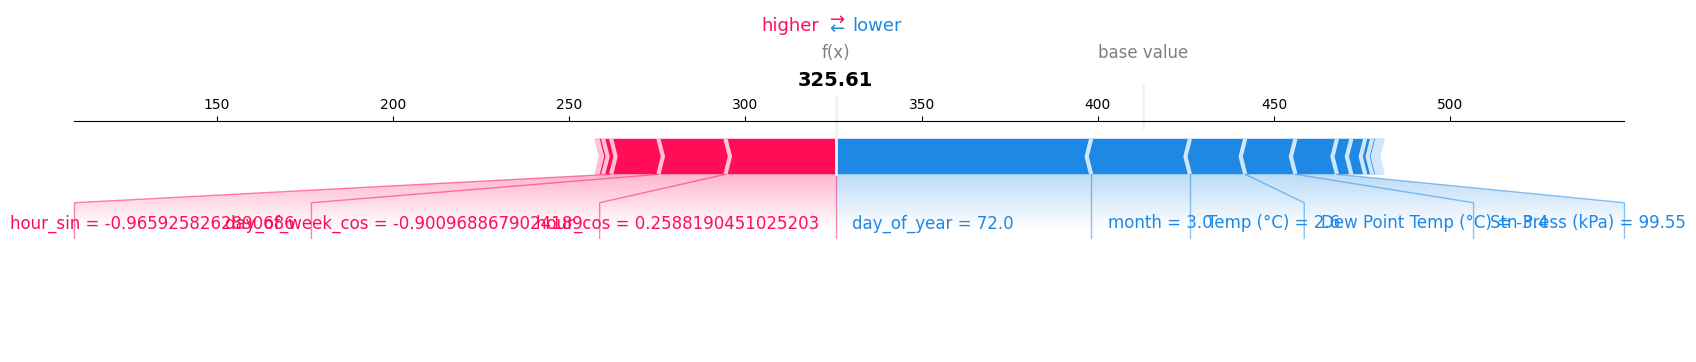

In [71]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    X_test_encoded_cupy[0, :].get(),
    feature_names=feature_names,
    matplotlib=True,
)

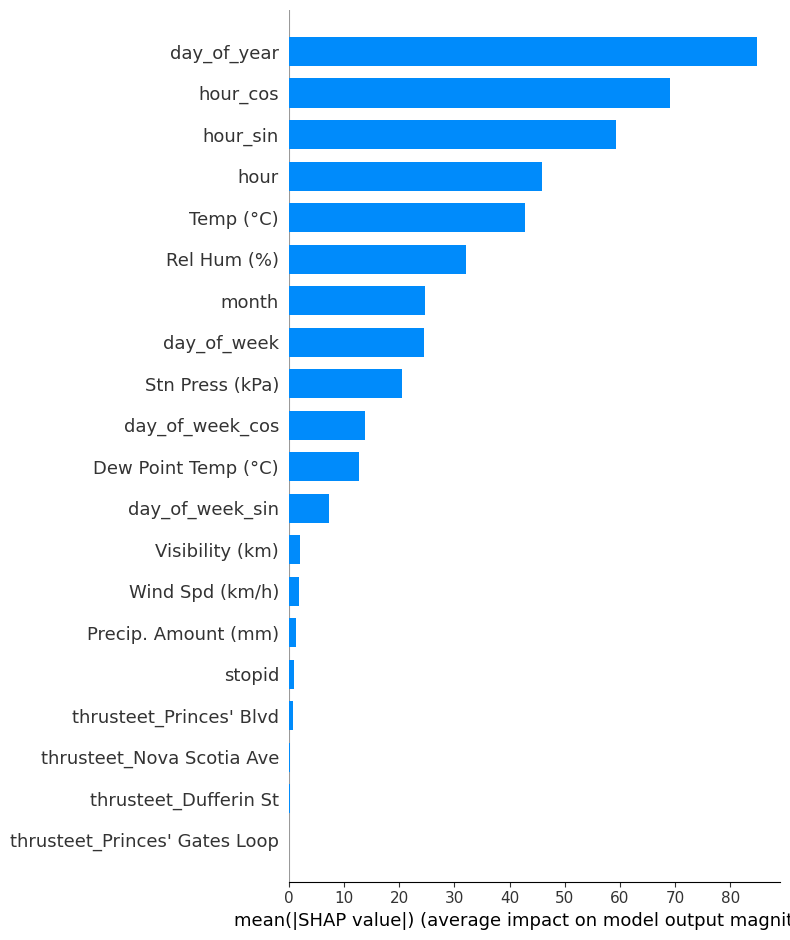

In [49]:
shap.summary_plot(shap_values, X_test_encoded_cupy, plot_type="bar", feature_names=feature_names)

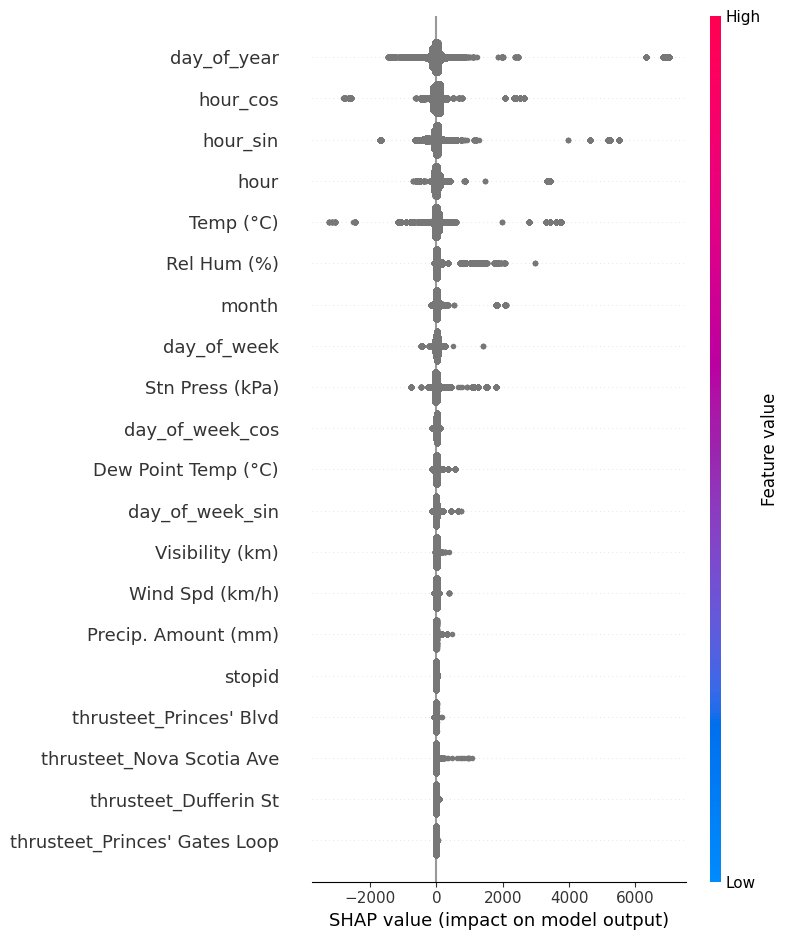

In [50]:
shap.summary_plot(shap_values, X_test_encoded_cupy, feature_names=feature_names)

## Model without categorical data

### Simple Model

In [81]:
cp.get_default_memory_pool().free_all_blocks()

In [96]:
df_without_encoding_X = df_without_encoding.drop(columns=['delay_seconds', 'route', 'trip_id', 'thrusteet', 'actual_arrival', 'nearest_whole_hour'])
df_without_encoding_y = df_without_encoding['delay_seconds']

In [97]:
df_without_encoding_X.head()

,stopid,hour,day_of_week,month,day_of_year,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,Climate ID,Temp (°C),Dew Point Temp (°C),Rel Hum (%),Wind Spd (km/h),Visibility (km),Stn Press (kPa),Precip. Amount (mm),bound
0,34800,0,2,1,1,0.0,1.0,0.974928,-0.222521,6158731.0,1.6,1.6,100.0,27.0,16.1,97.93,0.5,0
1,1361,0,2,1,1,0.0,1.0,0.974928,-0.222521,6158731.0,1.6,1.6,100.0,27.0,16.1,97.93,0.5,0
2,2815,0,2,1,1,0.0,1.0,0.974928,-0.222521,6158731.0,1.6,1.6,100.0,27.0,16.1,97.93,0.5,0
3,9023,0,2,1,1,0.0,1.0,0.974928,-0.222521,6158731.0,1.6,1.6,100.0,27.0,16.1,97.93,0.5,0
4,18388,0,2,1,1,0.0,1.0,0.974928,-0.222521,6158731.0,1.6,1.6,100.0,27.0,16.1,97.93,0.5,0


In [98]:
X_train_without_encoding, X_test_without_encoding, y_train_without_encoding, y_test_without_encoding = train_test_split(
    df_without_encoding_X,
    df_without_encoding_y,
    test_size=0.2,
    random_state=42
)

print(f"\nTrain size: {len(X_train_without_encoding):,}")
print(f"Test size: {len(X_test_without_encoding):,}")


Train size: 1,614,656
Test size: 403,664


In [99]:
X_train_without_encoding_cupy = X_train_without_encoding.to_cupy()
y_train_without_encoding_cupy = y_train_without_encoding.to_cupy()
X_test_without_encoding_cupy = X_test_without_encoding.to_cupy()
y_test_without_encoding_cupy = y_test_without_encoding.to_cupy()

In [100]:
# # Define Optuna objective function for hyperparameter tuning
import numpy as np
def objective(trial):
    """Optuna objective function to minimize RMSE using native XGBoost Dask API"""
    
    # Define hyperparameter search space
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'device': 'cuda',
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 10_000,20_000, step=1000),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    
    n_samples = X_train_without_encoding_cupy.shape[0]
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    avg_r2_squares = np.zeros(kf.get_n_splits())
    
    # KFold.split only needs sample count — pass a range, no GPU→CPU data transfer
    for i, (train_index, val_index) in enumerate(kf.split(range(n_samples))):
        # Index cupy arrays directly with numpy indices
        dtrain = xgb.QuantileDMatrix(X_train_without_encoding_cupy[train_index], label=y_train_without_encoding_cupy[train_index])
        dval = xgb.QuantileDMatrix(X_train_without_encoding_cupy[val_index], label=y_train_without_encoding_cupy[val_index], ref=dtrain)

        model = xgb.train(params, dtrain, evals=[(dval, 'eval')], 
                      verbose_eval=False, early_stopping_rounds=100)
    
        # Make predictions (returns numpy array)
        y_pred = model.predict(dval)
    
        # Convert only the fold's labels to numpy for R2 score calculation
        y_fold = y_train_without_encoding_cupy[val_index].get()
        r2_square = r2_score(y_fold, y_pred)
        avg_r2_squares[i] = r2_square

    # Return average R2 square across folds
    return float(np.mean(avg_r2_squares))

print("Objective function defined with native XGBoost and Optuna GPU")

Objective function defined with native XGBoost and Optuna GPU


In [101]:
# Run Optuna hyperparameter optimization
print("Starting Optuna hyperparameter optimization...")
print("XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.")
print("This may take a while...\n")



# Create study
study_simple_without_encoding = optuna.create_study(
    direction='maximize',  # Maximize R2 square
    study_name='xgboost_delay_prediction',
    sampler=optuna.samplers.TPESampler(seed=42),
)

# Run optimization sequentially (XGBoost Dask handles parallelization internally)
n_trials = 50  # Total number of trials

print(f"Running {n_trials} trials...")

# Run sequential optimization - each trial uses Dask cluster efficiently
study_simple_without_encoding.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)
print(f"\nBest trial: #{study_simple_without_encoding.best_trial.number}")
print(f"Best RMSE: {study_simple_without_encoding.best_value:.4f}")
print("\nBest hyperparameters:")
for key, value in study_simple_without_encoding.best_params.items():
    print(f"  {key}: {value}")

[I 2026-03-22 20:39:31,379] A new study created in memory with name: xgboost_delay_prediction


Starting Optuna hyperparameter optimization...
XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.
This may take a while...

Running 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]

/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:39:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:39:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:39:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:39:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-22 20:39:32,187] Trial 0 finished with value: 0.7519227362118217 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 18000, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746}. Best is trial 0 with value: 0.7519227362118217.


...

[I 2026-03-22 20:40:36,176] Trial 47 finished with value: 0.8238064412762085 and parameters: {'max_depth': 9, 'learning_rate': 0.19723522098898927, 'n_estimators': 15000, 'subsample': 0.892424726376194, 'colsample_bytree': 0.8621215469150979}. Best is trial 17 with value: 0.8494592997601643.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:40:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:40:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:40:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:40:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-22 20:40:37,815] Trial 48 finished with value: 0.8468505450623806 and parameters: {'max_depth': 10, 'learning_rate': 0.26297045342943187, 'n_estimators': 15000, 'subsample': 0.8148129934613271, 'colsample_bytree': 0.7800117826585272}. Best is trial 17 with value: 0.8494592997601643.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:40:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:40:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:40:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[20:40:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-22 20:40:38,881] Trial 49 finished with value: 0.8142495812525302 and parameters: {'max_depth': 8, 'learning_rate': 0.2005072009509662, 'n_estimators': 17000, 'subsample': 0.828998687253169, 'colsample_bytree': 0.7362225719872795}. Best is trial 17 with value: 0.8494592997601643.

OPTIMIZATION COMPLETE!

Best trial: #17
Best RMSE: 0.8495

Best hyperparameters:
  max_depth: 10
  learning_rate: 0.28668645969289
  n_estimators: 13000
  subsample: 0.6391499290124204
  colsample_bytree: 0.9984067957444854


In [102]:
fig = optuna.visualization.plot_param_importances(study_simple_without_encoding)
show(fig)

In [103]:
study_simple_without_encoding.best_params

{'max_depth': 10,
 'learning_rate': 0.28668645969289,
 'n_estimators': 13000,
 'subsample': 0.6391499290124204,
 'colsample_bytree': 0.9984067957444854}

In [104]:
cp.get_default_memory_pool().free_all_blocks()

In [105]:
# Train final model with best parameters using native XGBoost Dask API
print("Training final model with best hyperparameters...")
print("="*60)

# Get best parameters
best_params_simple = study_simple_without_encoding.best_params.copy()
best_params_clean = {k: v for k, v in best_params_simple.items() if k != 'num_boost_round'}
best_params_simple['objective'] = 'reg:squarederror'
best_params_simple['tree_method'] = 'hist'  # Required for Dask

# Create QuantileDMatrix for training
dtrain = xgb.DMatrix(X_train_without_encoding_cupy, y_train_without_encoding_cupy)

# Train final model using native Dask XGBoost
output_simple_without_encoding = xgb.train(
    best_params_simple,
    dtrain,
)

Training final model with best hyperparameters...


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning:

[20:40:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




In [106]:
dtest = xgb.DMatrix(X_test_without_encoding_cupy)
y_pred_dropped = output_simple_without_encoding.predict(dtest)

In [107]:
rmse_simple_without_encoding = np.sqrt(mean_squared_error(y_test_without_encoding_cupy.get(), y_pred_dropped))
r2_simple_without_encoding = r2_score(y_test_without_encoding_cupy.get(), y_pred_dropped)
mae_simple_without_encoding = mean_absolute_error(y_test_without_encoding_cupy.get(), y_pred_dropped)
print("Final Model Performance on Test Set:")
print(f"  RMSE: {rmse_simple_without_encoding:.4f}")
print(f"  R²: {r2_simple_without_encoding:.4f}")
print(f"  MAE: {mae_simple_without_encoding:.4f}")

Final Model Performance on Test Set:
  RMSE: 413.9975
  R²: 0.8456
  MAE: 256.0864


In [108]:
# calculate gain feature importance percentages and show in table
import pandas as pd
map_with_features = output_simple_without_encoding.get_score(importance_type='gain')
feature_importance_df = pd.DataFrame(map_with_features.items(), columns=['Feature', 'Gain'])
feature_importance_df['Feature'] = feature_importance_df['Feature'].apply(lambda x: df_without_encoding_X.columns[int(x[1:])])
feature_importance_df = feature_importance_df.sort_values(by='Gain', ascending=False)
total_gain = feature_importance_df['Gain'].sum()
feature_importance_df['Gain Percentage'] = (feature_importance_df['Gain'] / total_gain) * 100
print(feature_importance_df)

                Feature          Gain  Gain Percentage
9             Temp (°C)  1.548653e+09        34.490712
6              hour_cos  6.474694e+08        14.420070
7       day_of_week_sin  6.103597e+08        13.593585
5              hour_sin  5.183437e+08        11.544256
4           day_of_year  3.905245e+08         8.697540
2           day_of_week  1.320773e+08         2.941551
3                 month  1.207779e+08         2.689896
10  Dew Point Temp (°C)  1.052475e+08         2.344012
14      Stn Press (kPa)  1.048976e+08         2.336221
1                  hour  8.437955e+07         1.879253
11          Rel Hum (%)  7.266083e+07         1.618261
8       day_of_week_cos  6.063013e+07         1.350320
12      Wind Spd (km/h)  3.616188e+07         0.805377
15  Precip. Amount (mm)  2.924332e+07         0.651291
13      Visibility (km)  1.856848e+07         0.413547
16                bound  7.410410e+06         0.165040
0                stopid  2.652257e+06         0.059070


In [109]:
output_simple_without_encoding.set_param({'device': 'cuda'})

In [110]:
import shap
shap_values = output_simple_without_encoding.predict(dtest, pred_contribs=True)
explainer = shap.TreeExplainer(output_simple_without_encoding)
shap_values = explainer.shap_values(X_test_without_encoding_cupy)
feature_names = df_without_encoding_X.columns.tolist()

In [111]:
shap_values

array([[ 9.1967840e+00,  2.6451746e+01,  1.7207548e+01, ...,
        -2.9862888e+00, -1.4327839e+01,  7.9359555e-01],
       [-5.1554842e+00,  4.3252800e+01,  2.2761772e+00, ...,
         1.1165363e+02, -1.1553843e+00, -4.7431907e-01],
       [ 9.2386347e-01, -2.4762487e+01,  4.6384282e+00, ...,
        -1.3623884e+01, -1.0599771e+01,  4.3911148e-02],
       ...,
       [ 2.8256912e+00, -1.3844511e+02,  2.9055006e+01, ...,
         9.2793228e+01, -3.1935805e-01,  4.5793738e-02],
       [-6.4655824e+00, -4.1184696e+01, -5.1728401e+00, ...,
        -3.1089909e+01, -1.2674248e+00,  1.6438438e-02],
       [ 2.2644045e+01, -3.2307732e+01,  1.8861906e+01, ...,
        -6.1498657e+01, -2.8161415e-01, -5.0399359e-02]],
      shape=(403664, 18), dtype=float32)

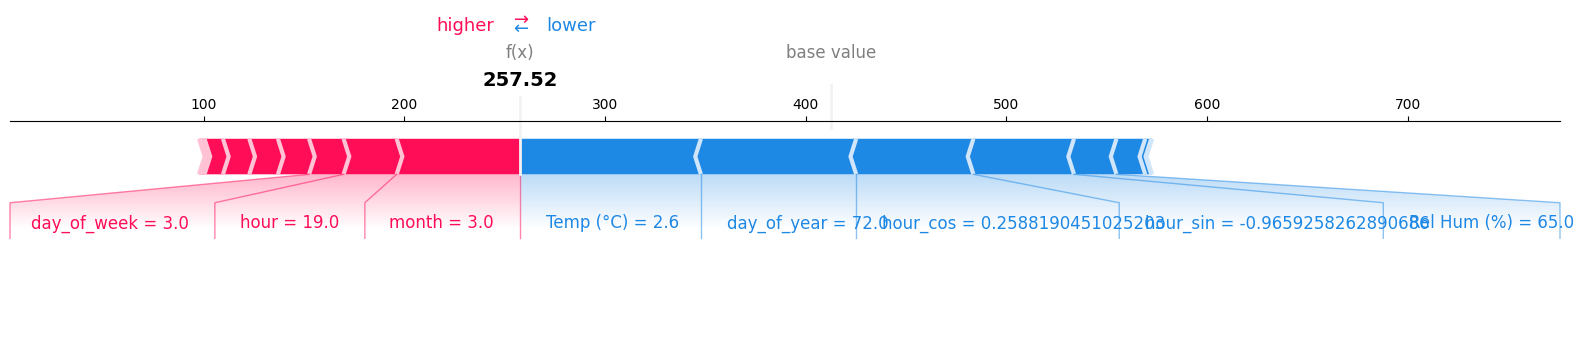

In [112]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    X_test_without_encoding_cupy[0, :].get(),
    feature_names=feature_names,
    matplotlib=True,
)

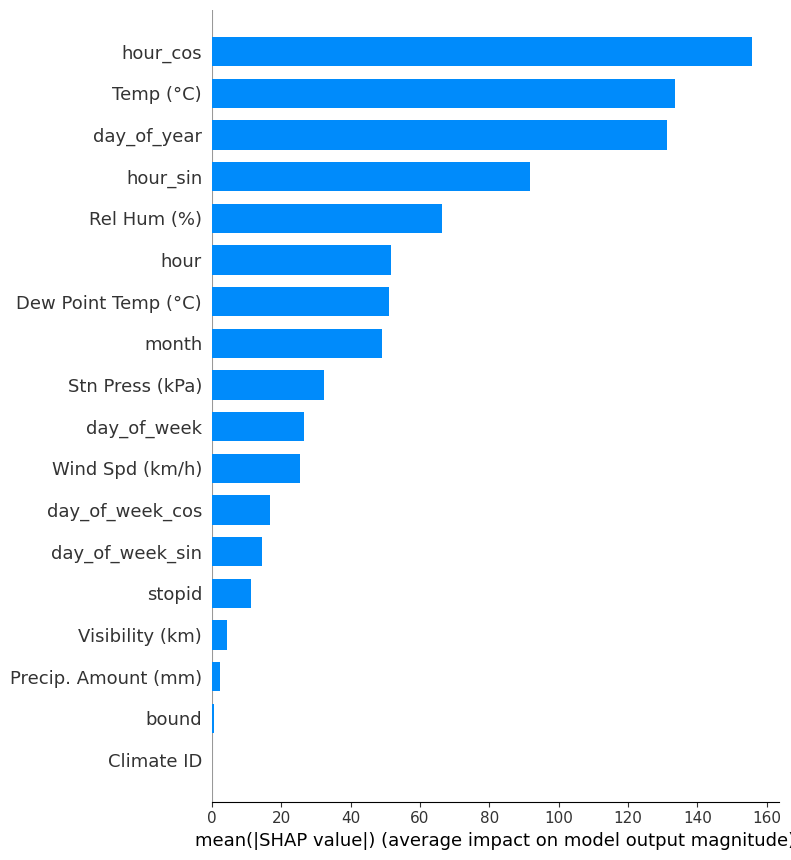

In [113]:
shap.summary_plot(shap_values, X_test_without_encoding_cupy, plot_type="bar", feature_names=feature_names)

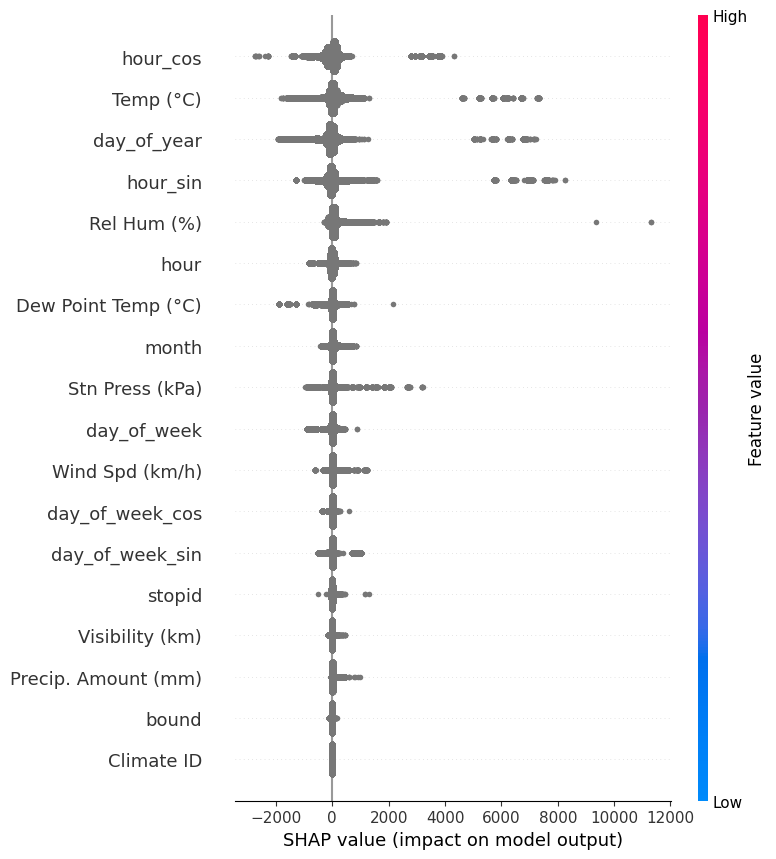

In [115]:
import matplotlib.pyplot as plt
shap.summary_plot(shap_values, X_test_without_encoding_cupy, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()

### Complex Model

In [74]:
def objective(trial):
    """Optuna objective function to minimize RMSE using native XGBoost Dask API"""
    
    # Define hyperparameter search space
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'device': 'cuda',
        # Use max_leaves instead of or alongside max_depth for more flexible trees
        'max_leaves': trial.suggest_int('max_leaves', 31, 512),
        'grow_policy': 'lossguide',  # Required for max_leaves to work with hist
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 10_000,15_000, step=1000),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        # L2 regularization on leaf weights (default=1)
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),

        # L1 regularization on leaf weights (default=0)
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),

        # Minimum loss reduction for further partitioning (default=0)
        'gamma': trial.suggest_float('gamma', 0, 5.0),

        # Minimum child weight — prevents overfitting to small leaf nodes
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'colsample_bynode': trial.suggest_float('colsample_bynode', 0.5, 1.0),
        
    }
    
    n_samples = X_train_without_encoding_cupy.shape[0]
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
        
    avg_r2_scores = np.zeros(kf.get_n_splits())
    
    # KFold.split only needs sample count — pass a range, no GPU→CPU data transfer
    for i, (train_index, val_index) in enumerate(kf.split(range(n_samples))):
        # Index cupy arrays directly with numpy indices
        dtrain = xgb.QuantileDMatrix(X_train_without_encoding_cupy[train_index], label=y_train_without_encoding_cupy[train_index])
        dval = xgb.QuantileDMatrix(X_train_without_encoding_cupy[val_index], label=y_train_without_encoding_cupy[val_index], ref=dtrain)

        model = xgb.train(params, dtrain, evals=[(dval, 'eval')], 
                      verbose_eval=False, early_stopping_rounds=100)
    
        # Make predictions (returns numpy array)
        y_pred = model.predict(dval)
    
        # Convert only the fold's labels to numpy for RMSE calculation
        y_fold = y_train_without_encoding_cupy[val_index].get()
        r2_scores = r2_score(y_fold, y_pred)
        avg_r2_scores[i] = r2_scores

        trial.report(np.mean(avg_r2_scores), i)
        if trial.should_prune():
            raise optuna.TrialPruned()
        
    # Return average R2 across folds
    return float(np.mean(avg_r2_scores))

print("Objective function defined with native XGBoost and Optuna GPU")

Objective function defined with native XGBoost and Optuna GPU


In [75]:
# Run Optuna hyperparameter optimization
print("Starting Optuna hyperparameter optimization...")
print("XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.")
print("This may take a while...\n")



# Create study with optuna
study_complex_without_encoding = optuna.create_study(
    direction='maximize',  # Maximize R2 square
    study_name='xgboost_delay_prediction',
    sampler=optuna.samplers.TPESampler(seed=42),
)

# Run optimization sequentially (XGBoost Dask handles parallelization internally)
n_trials = 50  # Total number of trials

print(f"Running {n_trials} trials...")

# Run sequential optimization - each trial uses Dask cluster efficiently
study_complex_without_encoding.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)
print(f"\nBest trial: #{study_complex_without_encoding.best_trial.number}")
print(f"Best RMSE: {study_complex_without_encoding.best_value:.4f}")
print("\nBest hyperparameters:")
for key, value in study_complex_without_encoding.best_params.items():
    print(f"  {key}: {value}")

[I 2026-03-22 15:34:02,339] A new study created in memory with name: xgboost_delay_prediction


Starting Optuna hyperparameter optimization...
XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.
This may take a while...

Running 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]

/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[15:34:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[15:34:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[15:34:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[15:34:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-22 15:34:04,080] Trial 0 finished with value: 0.7598661894739462 and parameters: {'max_leaves': 211, 'learning_rate': 0.24517932047070642, 'n_estimators': 14000, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_lambda': 0.004207053950287938, 'reg_alpha': 0.0017073967431528124, 'gamma': 4.330880728874676, 'min_child_weight': 31, 'colsample_bylevel': 0.8540362888980227, 'colsample_bynode': 0.5102922471479012}. Best is trial 0 with value: 0.7598661894739462.


...

[I 2026-03-22 15:34:53,757] Trial 47 pruned. 


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[15:34:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




[I 2026-03-22 15:34:54,074] Trial 48 pruned. 


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[15:34:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




[I 2026-03-22 15:34:54,416] Trial 49 pruned. 

OPTIMIZATION COMPLETE!

Best trial: #30
Best RMSE: 0.8022

Best hyperparameters:
  max_leaves: 189
  learning_rate: 0.29028101538531925
  n_estimators: 14000
  subsample: 0.828102988490585
  colsample_bytree: 0.7801491293829173
  reg_lambda: 2.4484524848809306
  reg_alpha: 1.4922534926226652
  gamma: 2.250496851038464
  min_child_weight: 1
  colsample_bylevel: 0.9090866360521802
  colsample_bynode: 0.853276743251372


In [76]:
fig = optuna.visualization.plot_param_importances(study_complex_without_encoding)
show(fig)

In [77]:
study_complex_without_encoding.best_params

{'max_leaves': 189,
 'learning_rate': 0.29028101538531925,
 'n_estimators': 14000,
 'subsample': 0.828102988490585,
 'colsample_bytree': 0.7801491293829173,
 'reg_lambda': 2.4484524848809306,
 'reg_alpha': 1.4922534926226652,
 'gamma': 2.250496851038464,
 'min_child_weight': 1,
 'colsample_bylevel': 0.9090866360521802,
 'colsample_bynode': 0.853276743251372}

In [78]:
cp.get_default_memory_pool().free_all_blocks()

In [79]:
# Train final model with best parameters using native XGBoost Dask API
print("Training final model with best hyperparameters...")
print("="*60)

# Get best parameters
best_params_complex = study_complex_without_encoding.best_params.copy()
best_params_clean = {k: v for k, v in best_params_complex.items() if k != 'num_boost_round'}
best_params_complex['objective'] = 'reg:squarederror'
best_params_complex['tree_method'] = 'hist'  # Required for Dask

# Create QuantileDMatrix for training
dtrain = xgb.DMatrix(X_train_without_encoding_cupy, y_train_without_encoding_cupy)

# Train final model using native Dask XGBoost
output_complex_without_encoding = xgb.train(
    best_params_complex,
    dtrain,
)

Training final model with best hyperparameters...


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning:

[15:35:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




In [80]:
dtest = xgb.DMatrix(X_test_without_encoding_cupy)
y_pred_dropped = output_complex_without_encoding.predict(dtest)

In [82]:
rmse_complex_without_encoding = np.sqrt(mean_squared_error(y_test_without_encoding_cupy.get(), y_pred_dropped))
r2_complex_without_encoding = r2_score(y_test_without_encoding_cupy.get(), y_pred_dropped)
mae_complex_without_encoding = mean_absolute_error(y_test_without_encoding_cupy.get(), y_pred_dropped)
print("Final Model Performance on Test Set:")
print(f"  RMSE: {rmse_complex_without_encoding:.4f}")
print(f"  R²: {r2_complex_without_encoding:.4f}")
print(f"  MAE: {mae_complex_without_encoding:.4f}")

Final Model Performance on Test Set:
  RMSE: 476.9700
  R²: 0.7951
  MAE: 289.4056


In [ ]:
import pandas as pd
map_with_features = output_complex_without_encoding.get_score(importance_type='gain')
feature_importance_df = pd.DataFrame(map_with_features.items(), columns=['Feature', 'Gain'])
feature_importance_df['Feature'] = feature_importance_df['Feature'].apply(lambda x: df_without_encoding_X.columns[int(x[1:])])
feature_importance_df = feature_importance_df.sort_values(by='Gain', ascending=False)
print(feature_importance_df)

In [83]:
output_complex_without_encoding.set_param({'device': 'cuda'})

In [84]:
shap_values = output_complex_without_encoding.predict(dtest, pred_contribs=True)
explainer = shap.TreeExplainer(output_complex_without_encoding)
shap_values = explainer.shap_values(X_test_without_encoding_cupy)
feature_names = df_without_encoding_X.columns.tolist()

In [85]:
shap_values

array([[-2.08931658e-02,  2.95744667e+01,  5.59763956e+00, ...,
        -2.19825611e+01, -2.57977605e+00, -1.05795385e-04],
       [-3.30993161e-02, -3.40963837e+02,  1.45411472e+01, ...,
         5.19626617e+01,  6.93683699e-02, -3.52077332e-05],
       [-2.12060623e-02, -2.21081600e+01, -3.42794991e+00, ...,
        -8.43353653e+00, -3.31558967e+00, -1.52790290e-05],
       ...,
       [-1.15137480e-01, -8.02380276e+00,  6.63627100e+00, ...,
         1.10765228e+01, -8.35481048e-01, -7.95125197e-06],
       [-7.03717321e-02, -2.59160366e+01,  5.12571859e+00, ...,
         3.28513069e+01, -3.02528948e-01, -1.52790290e-05],
       [-2.98159346e-02, -1.29816027e+01,  1.02285175e+01, ...,
        -2.31621075e+01,  1.02451548e-01, -8.40497341e-06]],
      shape=(403664, 18), dtype=float32)

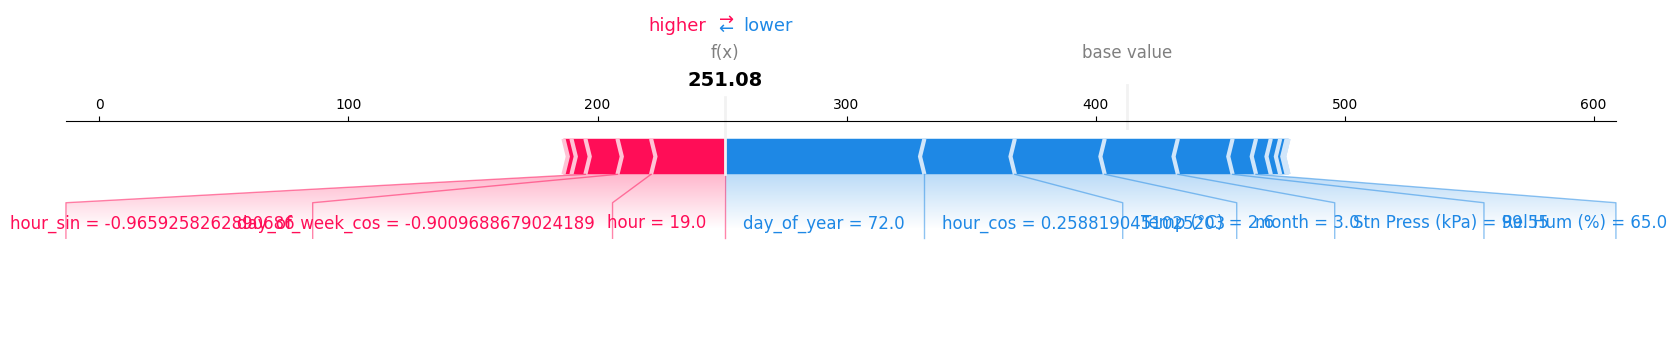

In [86]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    X_test_without_encoding_cupy[0, :].get(),
    feature_names=feature_names,
    matplotlib=True,
)

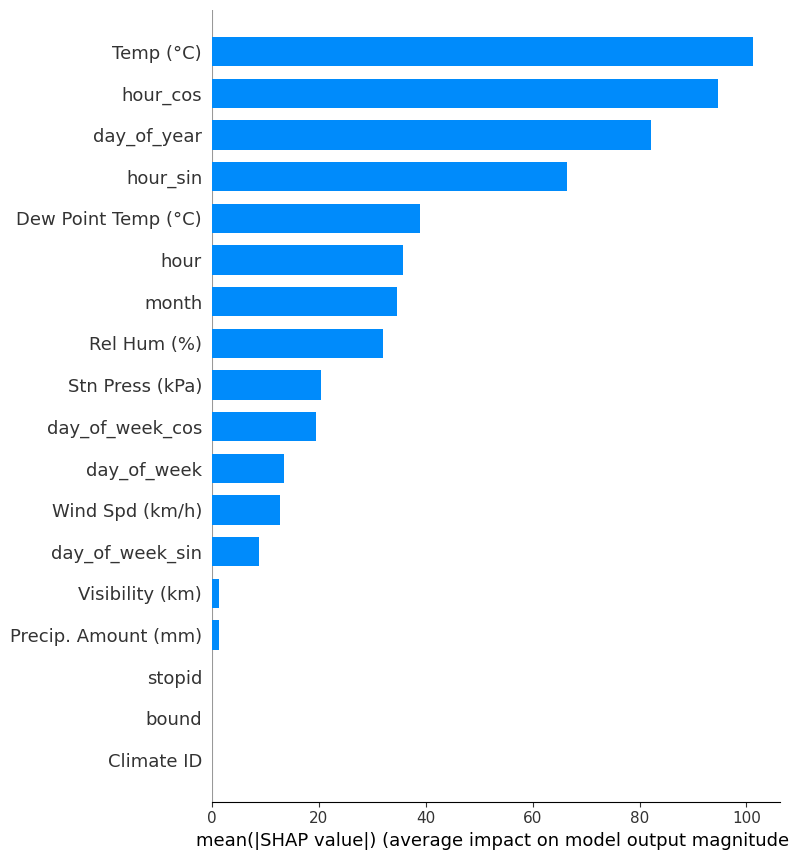

In [87]:
shap.summary_plot(shap_values, X_test_without_encoding_cupy, plot_type="bar", feature_names=feature_names)

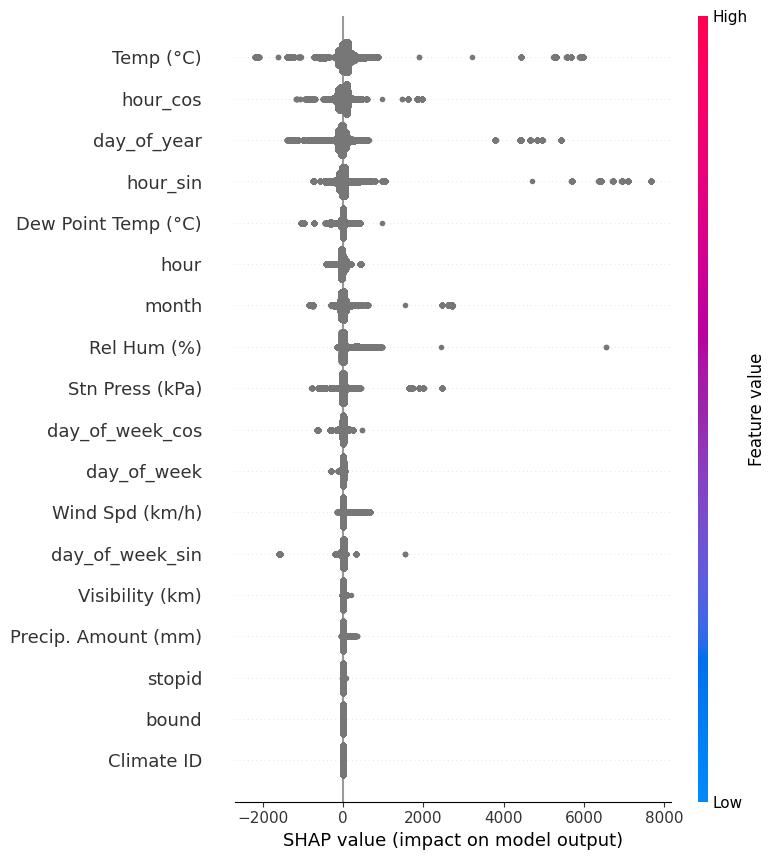

In [88]:
shap.summary_plot(shap_values, X_test_without_encoding_cupy, feature_names=feature_names)

## Model Comparison

In [89]:
# now we make chart of complex vs simple, rmse and r2 in two figure using plotly
from plotly.subplots import make_subplots
import plotly.graph_objects as go

rmse = [rmse_simple_without_encoding, rmse_complex_without_encoding, rmse_simple_encoded, rmse_complex_encoded]
r2 = [r2_simple_without_encoding, r2_complex_without_encoding, r2_simple_encoded, r2_complex_encoded]
mae = [mae_simple_without_encoding, mae_complex_without_encoding, mae_simple_encoded, mae_complex_encoded]
models = ['Simple Model', 'Complex Model', 'Simple Model (Encoded)', 'Complex Model (Encoded)']

# using 1,2 subplot
fig = make_subplots(rows=1, cols=3, subplot_titles=('RMSE', 'R²', 'MAE'))
fig.add_trace(go.Bar(x=models, y=rmse), row=1, col=1)
fig.add_trace(go.Bar(x=models, y=r2), row=1, col=2)
fig.add_trace(go.Bar(x=models, y=mae), row=1, col=3)
fig.update_layout(title_text='Model Performance Comparison', showlegend=False)
fig.update_xaxes(title_text='Model', row=1, col=1)
fig.update_xaxes(title_text='Model', row=1, col=2)
fig.update_yaxes(title_text='RMSE', row=1, col=1)
fig.update_yaxes(title_text='R²', row=1, col=2)
fig.update_yaxes(title_text='MAE', row=1, col=3)

fig.show()